# Project Milestone 3

In [165]:
pip install html5lib

Note: you may need to restart the kernel to use updated packages.


In [166]:
# Importing Pandas packages required for this excercise.

import pandas as pd
import requests
import html5lib
import matplotlib
from matplotlib import pyplot as plt

In [167]:
# loading covid CSV file for data transformation and cleaning

url = 'https://en.wikipedia.org/wiki/COVID-19_pandemic_by_country_and_territory'

In [169]:
dfs = pd.read_html(url)

In [172]:
corona_df=dfs[12]
corona_df

,Unnamed: 0,Country,Deaths / million,Deaths,Cases
0,NaN,World[a],883,7057132,775866783
1,NaN,Peru,6601,220975,4526977
2,NaN,Bulgaria,5669,38700,1329988
3,NaN,North Macedonia,5422,9978,350924
4,NaN,Bosnia and Herzegovina,5114,16392,403666
...,...,...,...,...,...
235,NaN,Pitcairn Islands,0,0,4
236,NaN,Tokelau,0,0,80
237,NaN,North Korea,0,0,0
238,NaN,Turkmenistan,0,0,0


In [173]:
corona_df_col=corona_df.drop(columns=['Unnamed: 0'])

In [177]:
#Clean Country column data

corona_df_col['Country'].str.replace('[/,.*]','')

0                                               World[a]
1                                                   Peru
2                                               Bulgaria
3                                        North Macedonia
4                                 Bosnia and Herzegovina
                             ...                        
235                                     Pitcairn Islands
236                                              Tokelau
237                                          North Korea
238                                         Turkmenistan
239    ^ Countries which do not report data for a col...
Name: Country, Length: 240, dtype: object

In [179]:
# remove records where deaths are equals to 0 or less
corona_df_clean=corona_df_col[(corona_df_col['Deaths'])>"0"]

In [181]:
corona_df_clean

,Country,Deaths / million,Deaths,Cases
0,World[a],883,7057132,775866783
1,Peru,6601,220975,4526977
2,Bulgaria,5669,38700,1329988
3,North Macedonia,5422,9978,350924
4,Bosnia and Herzegovina,5114,16392,403666
...,...,...,...,...
227,Tajikistan,12,125,17786
228,Benin,11,163,28036
229,Chad,10,194,7702
230,Burundi,1,15,54569


In [183]:
# remove all the unwanted rows from the dataframe

corona_remove_un_rows=corona_df_col.drop([239])

In [185]:
corona_remove_un_rows

,Country,Deaths / million,Deaths,Cases
0,World[a],883,7057132,775866783
1,Peru,6601,220975,4526977
2,Bulgaria,5669,38700,1329988
3,North Macedonia,5422,9978,350924
4,Bosnia and Herzegovina,5114,16392,403666
...,...,...,...,...
234,"Saint Helena, Ascension and Tristan da Cunha",0,0,2166
235,Pitcairn Islands,0,0,4
236,Tokelau,0,0,80
237,North Korea,0,0,0


In [234]:
corona_df_1=dfs[15]
corona_df_1 = corona_df_1.rename(columns={'Region[30]': 'Region', 'Vacci­nated %[31]': 'Vacci­nated'})
corona_df_1 = corona_df_1[['Region', 'Cases per million']]


In [236]:
Covidsort = corona_remove_un_rows.sort_values(by = 'Deaths',ascending = True)
Covidsort

,Country,Deaths / million,Deaths,Cases
238,Turkmenistan,0,0,0
232,Niue,0,0,1074
236,Tokelau,0,0,80
237,North Korea,0,0,0
235,Pitcairn Islands,0,0,4
...,...,...,...,...
76,Denmark,1642,9693,3435679
62,Republic of Ireland,1906,9744,1745088
18,Lithuania,3482,9810,1369355
167,Mauritania,204,997,63872


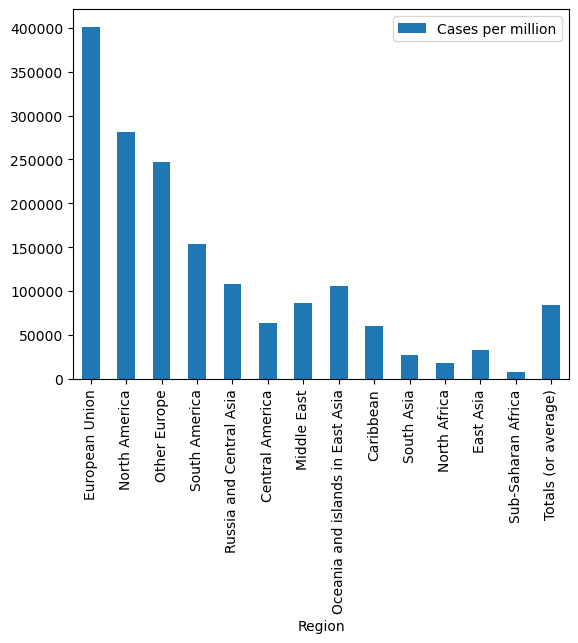

In [238]:
corona_df_1.plot(x='Region', y='Cases per million', kind='bar')
plt.show()